# 2 Feature Engineering & Exploration

Risk Factors: https://www.cdc.gov/heart-disease/risk-factors/index.html  

Heart disease risk is shaped by a combination of clinical, lifestyle, and genetic factors. Key risk factors include high blood pressure, high cholesterol, smoking, physical inactivity, and family history — some of which can be controlled, others cannot.

Our goal is to build a model that helps individuals identify their risk category and understand which factors contribute to it, enabling them to take targeted steps toward reducing controllable risks.

While our dataset already captures many of these factors directly, raw columns alone do not always reflect the full picture. For example, the individual effect of high BMI tells a different story than high BMI combined with high cholesterol or advanced age. We therefore engineer additional features that better capture these compound relationships, improve model performance, and enhance interpretability for medical personnel working with the final product.

In [1]:
# Load Data
import pandas as pd

df = pd.read_csv("data/raw/cardiovascular_risk_dataset.csv")
df.head()

,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


## 2.1 Data Cleaning

Before exploring which additional features could be created to consider the risk factors, we clean our original dataframe, based on what we found out in the EDA. As we did not find any missing values or duplicates, we will only drop columns. We will drop Patient_ID, as it is a unique identifier without any predictive value, and we will drop heart_disease_risk_score, as it directly encodes with our target (risk_category), which would cause leakage. 

In [2]:
# Drop Patient_ID and heart_disease_risk_score in a new dataframe so we do not change our original one 
df_clean = df.copy()

df_clean = df_clean.drop(columns=['Patient_ID', 'heart_disease_risk_score'])

print("Cleaned dataframe shape:", df_clean.shape)
print("Columns: ", df_clean.columns.tolist())

Cleaned dataframe shape: (5500, 15)
Columns:  ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl', 'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level', 'physical_activity_hours_per_week', 'sleep_hours', 'family_history_heart_disease', 'diet_quality_score', 'alcohol_units_per_week', 'risk_category']


## 2.2 Feature Creation

As mentioned above, there are certain risk factors for getting a heart disease. While our dataset already provides some of these factors, by creating new features from the existing ones, we aim to better capture relationships that raw columns cannot express directly. We organise our engineered features into three categories: polynomial transformations, interaction features, and binned flag features.

**Polynomial transformations** (age_squared, bmi_squared): cardiovascular risk does not increase at a constant rate with age or BMI but accelerates at higher values. Squaring these variables allows models to reflect that non-linear behaviour.

**Interaction & ratio features** (pulse_pressure, map, bmi_x_age, bmi_x_cholesterol, cholesterol_age_ratio): these capture how two variables together create a stronger risk signal than either alone. For example, high BMI combined with high cholesterol represents a compounded metabolic risk, and high cholesterol at a younger age implies longer lifetime arterial exposure. Blood pressure variables are summarised into clinical metrics (Pulse Pressure and MAP) which are established markers of cardiovascular strain.

**Binary flag features** (hypertension_flag, obesity_flag, high_cholesterol_flag, inactivity_flag, sleep_deviation, alcohol_deviation): these encode clinically established thresholds directly, such as the WHO obesity threshold (BMI ≥ 30) or the hypertension boundary (systolic ≥ 140 or diastolic ≥ 90), giving models explicit and medically justified decision boundaries.

Not all engineered features will be used in the final models. Before modelling, we perform feature selection using Lasso to identify the most informative features before finalising our selection.

In [3]:
def feature_engineering(df):
    # Transform variables
    df['age_squared'] = df['age'] ** 2
    df['bmi_squared'] = df['bmi'] ** 2 

    # Add interactions
    df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
    df['map'] = df['diastolic_bp'] + (df['systolic_bp'] - df['diastolic_bp']) / 3
    df['bmi_x_age'] = df['bmi'] * df['age']
    df['bmi_x_cholesterol'] = df['bmi'] * df['cholesterol_mg_dl']
    df['cholesterol_age_ratio'] = df['cholesterol_mg_dl'] / df['age']

    # Add Binary/ binned features 
    df['hypertension_flag'] = ((df['systolic_bp'] >= 140) | (df['diastolic_bp'] >= 90)).astype(int)
    df['obesity_flag'] = (df['bmi'] >= 30).astype(int)
    df['high_cholesterol_flag'] = (df['cholesterol_mg_dl'] >= 240).astype(int)
    df['inactivity_flag'] = (df['daily_steps'] < 5000).astype(int)
    df['sleep_deviation'] = (df['sleep_hours'] - 7).abs()
    df['alcohol_deviation'] = df['alcohol_units_per_week'] - 14
    df['family_history_heart_disease'] = df['family_history_heart_disease'].map({'Yes': 1, 'No': 0})
    
    return df

## 2.3 Train-Test Split

We will now train-test-split the data. We will use stratify in order to ensure the same distribution of risk categories across the trained and test dataset. 

In [4]:
from sklearn.model_selection import train_test_split

df_all_features = feature_engineering(df_clean.copy())

# Define X/y
TARGET = "risk_category"
X = df_all_features.drop(columns=[TARGET])
y = df_all_features[TARGET]

# Split into training and testing set 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify preserves class distribution in both train and test sets

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in test set:\n", y_test.value_counts(normalize=True))

Training set size: (4400, 27)
Test set size: (1100, 27)

Class distribution in training set:
 risk_category
Medium    0.407955
Low       0.334318
High      0.257727
Name: proportion, dtype: float64

Class distribution in test set:
 risk_category
Medium    0.408182
Low       0.333636
High      0.258182
Name: proportion, dtype: float64


In [5]:
# Encode target variable with intuitive ordinal mapping (Low=0, Medium=1, High=2)
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

y_train_encoded = y_train.map(risk_mapping)
y_test_encoded = y_test.map(risk_mapping)

# Check the mapping
for cls, idx in risk_mapping.items():
    print(f"{cls} → {idx}")

print("\nTraining target distribution:\n", y_train_encoded.value_counts().sort_index())

Low → 0
Medium → 1
High → 2

Training target distribution:
 risk_category
0    1471
1    1795
2    1134
Name: count, dtype: int64


## 2.4 Preprocessing

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

binary_cols = [
    'hypertension_flag', 'obesity_flag', 'high_cholesterol_flag',
    'inactivity_flag', 'family_history_heart_disease'
]

numerical_cols = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl',
    'resting_heart_rate', 'daily_steps', 'stress_level',
    'physical_activity_hours_per_week', 'sleep_hours',
    'diet_quality_score', 'alcohol_units_per_week', 'age_squared',
    'bmi_squared', 'pulse_pressure', 'map', 'bmi_x_age', 'bmi_x_cholesterol',
    'cholesterol_age_ratio', 'sleep_deviation', 'alcohol_deviation'
]

categorical_cols = ['smoking_status']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('bin', 'passthrough', binary_cols)  # binary flags passed through unchanged
])

## 2.5 Feature Selection with LassoCV

The preprocessing step is applied to the full training set prior to feature selection. While this introduces a minor scaling leakage, its impact on feature selection is negligible as no target information is leaked. In a production setting, this step would be embedded inside a pipeline to ensure full cross-validation integrity.

In [7]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegressionCV

feature_names = (
    numerical_cols +
    list(preprocessor.named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_cols)) +
    binary_cols
)

logit_cv = LogisticRegressionCV(
    cv=5,
    penalty='l1',
    solver='saga',
    multi_class='multinomial',
    random_state=42,
    max_iter=10000
)
logit_cv.fit(X_train_processed, y_train_encoded)

# For multiclass, coef_ has shape (n_classes, n_features)
# Take the mean absolute coefficient across all classes
import numpy as np
coef_mean = np.mean(np.abs(logit_cv.coef_), axis=0)
coef_series = pd.Series(coef_mean, index=feature_names)
selected_features = coef_series[coef_series > 0].sort_values(ascending=False)

print(f"Features selected: {len(selected_features)}")
print(selected_features)

# Total features after engineering and encoding
total_features = X_train_processed.shape[1]
print(f"Total features after engineering and encoding: {total_features}")

C:\Users\lilik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1946: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Features selected: 23
family_history_heart_disease        3.174606
smoking_status_Current              3.165818
bmi_x_age                           2.632609
smoking_status_Never                1.667864
systolic_bp                         1.584582
physical_activity_hours_per_week    1.254892
cholesterol_mg_dl                   1.048970
diet_quality_score                  0.856180
age_squared                         0.701524
stress_level                        0.695555
age                                 0.480485
bmi_x_cholesterol                   0.379489
map                                 0.153961
bmi_squared                         0.111173
pulse_pressure                      0.088756
resting_heart_rate                  0.069807
high_cholesterol_flag               0.035445
sleep_deviation                     0.026352
alcohol_deviation                   0.017277
alcohol_units_per_week              0.017277
hypertension_flag                   0.015618
obesity_flag                     

In [9]:
# Select features with mean absolute coefficient above 0.1 (threshold can be adjusted)
selected_features = coef_series[coef_series >= 0.1].sort_values(ascending=False).index.tolist()

print(f"Features selected: {len(selected_features)}")
print(selected_features)

# Convert to DataFrame and filter to selected features
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

X_train_selected = X_train_processed_df[selected_features]
X_test_selected = X_test_processed_df[selected_features]

print("\nX_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

Features selected: 14
['family_history_heart_disease', 'smoking_status_Current', 'bmi_x_age', 'smoking_status_Never', 'systolic_bp', 'physical_activity_hours_per_week', 'cholesterol_mg_dl', 'diet_quality_score', 'age_squared', 'stress_level', 'age', 'bmi_x_cholesterol', 'map', 'bmi_squared']

X_train_selected shape: (4400, 14)
X_test_selected shape: (1100, 14)


# 3 Modeling

We train three classification models: Logistic Regression, Random Forest, and XGBoost. Each model uses the 14 features selected in the previous step. For every model we first establish a baseline using default hyperparameters and 5-fold cross-validation. We then perform hyperparameter tuning to identify the best configuration.

Throughout the modelling process we use F1 Macro as the primary evaluation metric. This metric calculates the F1 score separately for each risk category and then averages them equally. As a result, performance on the clinically important High risk class receives the same weight as the Medium and Low classes, which would not be guaranteed when using accuracy or weighted F1.

## 3.1 Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

log_reg = LogisticRegression(max_iter=1000, random_state=42)

scores = cross_val_score(log_reg, X_train_selected, y_train_encoded, 
                         cv=5, scoring='f1_macro')

print("Logistic Regression — Cross Validation Results")
print(f"F1 Score - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")

Logistic Regression — Cross Validation Results
F1 Score - Mean: 0.9411, Std: 0.0071


### 3.1.1 Hyperparameter Tuning

In [11]:
# Just out of compleness and curiosity - Hyperparameter Tuning 

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],  # fixed — supports both l1 and l2
    'max_iter': [1000]        # fixed — just ensure convergence
}

grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search_lr.fit(X_train_selected, y_train_encoded)

print("Best Parameters:", grid_search_lr.best_params_)
print(f"Best F1 Score:   {grid_search_lr.best_score_:.4f}")

Best Parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
Best F1 Score:   0.9418


## 3.2 Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Define model with default parameters
rf = RandomForestClassifier(random_state=42)

# Cross validate on training set
scores_rf = cross_val_score(rf, X_train_selected, y_train_encoded,
                            cv=5, scoring='f1_macro')

print("Random Forest — Cross Validation Results")
print(f"F1 Score — Mean: {scores_rf.mean():.4f}, Std: {scores_rf.std():.4f}")

Random Forest — Cross Validation Results
F1 Score — Mean: 0.9024, Std: 0.0051


### 3.2.1 Hyperparameter Tuning

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_selected, y_train_encoded)

print("Best Parameters:", grid_search_rf.best_params_)
print(f"Best F1 Macro:   {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best F1 Macro:   0.9062


## 3.3 XGBoost

In [14]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Define model with default parameters
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
)

# Cross validate on training set
scores_xgb = cross_val_score(xgb_model, X_train_selected, y_train_encoded,
                              cv=5, scoring='f1_macro')

print("XGBoost — Cross Validation Results")
print(f"F1 Score — Mean: {scores_xgb.mean():.4f}, Std: {scores_xgb.std():.4f}")

XGBoost — Cross Validation Results
F1 Score — Mean: 0.9135, Std: 0.0054


### 3.3.1 XGBoost - Hyperparameter Tuning

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],          # shallower trees
    'learning_rate': [0.01, 0.05],   # slower learning
    'subsample': [0.5, 0.6, 0.7],    # more aggressive subsampling
    'colsample_bytree': [0.5, 0.6],  # fewer features per tree
    'min_child_weight': [5, 10, 20], # higher = more conservative splits
    'gamma': [0.5, 1, 2, 5],        # higher = more conservative splits
    'reg_alpha': [0.1, 0.5, 1, 5],  # L1 regularization
    'reg_lambda': [1, 2, 5, 10]     # L2 regularization
}

random_search_xgb = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid_xgb,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_xgb.fit(X_train_selected, y_train_encoded)

print("Best Parameters:", random_search_xgb.best_params_)
print(f"Best F1 Score: {random_search_xgb.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.5, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.5}
Best F1 Score: 0.9220


# 4 Evaluation

We evaluate the performance of our three models (Logistic Regression, Random Forest, and XGBoost) on the held-out test set, which has not been touched during training or tuning.

Our primary metric is **F1 Macro**, which calculates F1 independently for each risk category and averages them equally. This ensures that strong performance on the frequent Medium class does not overshadow performance on the clinically critical High risk class.  In our business context, **Recall** is of particular importance. Failing to identify a High risk patient (false negative) carries far greater clinical consequences than a false alarm. We therefore additionally report **F2 Score** (F-Beta with β=2) as a supplementary clinical metric, which explicitly weights recall twice as heavily as precision to reflect this real-world cost. **ROC-AUC** is reported as another secondary metric reflecting overall discriminative ability.

We structure the evaluation as follows:
- **Classification Report**: per-class performance comparison across all three models
- **Overfitting Check**: train vs test F1 to confirm models generalise well
- **ROC-AUC Curve**: overall model comparison on a single chart
- **Confusion Matrix & SHAP**: detailed diagnostics for the best performing model

## 4.1 Overall Model Evaluation

In [16]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score, fbeta_score

# Helper function to evaluate any model cleanly
def evaluate_model(model, X_train, X_test, y_train, y_test, label):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    print(f"\n{label}")
    print("-" * 50)
    print(classification_report(y_test, y_pred,
                                target_names=['Low', 'Medium', 'High']))
    
    # Highlight primary metric
    print(f"\n Primary and Secondary Metrics")
    print("-" * 50)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f2_macro = fbeta_score(y_test, y_pred, beta=2, average='macro')
    roc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print(f"→ Primary Metric   | F1 Macro: {f1_macro:.4f}")
    print(f"→ Secondary Metric | F2 Score: {f2_macro:.4f}")
    print(f"→ Secondary Metric | ROC-AUC:  {roc:.4f}")
    
    # Overfitting check
    print(f"\nOverfitting Check")
    print("-" * 50)
    train_f1 = f1_score(y_train, model.predict(X_train), average='macro')
    test_f1  = f1_score(y_test,  model.predict(X_test),  average='macro')
    print(f"  Train F1 Macro: {train_f1:.4f}")
    print(f"  Test F1 Macro:  {test_f1:.4f}")
    print(f"  Difference:     {train_f1 - test_f1:.4f}")

In [17]:
# Logistic Regression
evaluate_model(grid_search_lr.best_estimator_,
               X_train_selected, X_test_selected,
               y_train_encoded, y_test_encoded,
               "Logistic Regression (Tuned)")


Logistic Regression (Tuned)
--------------------------------------------------
              precision    recall  f1-score   support

         Low       0.95      0.95      0.95       367
      Medium       0.92      0.94      0.93       449
        High       0.97      0.93      0.95       284

    accuracy                           0.94      1100
   macro avg       0.95      0.94      0.94      1100
weighted avg       0.94      0.94      0.94      1100


 Primary and Secondary Metrics
--------------------------------------------------
→ Primary Metric   | F1 Macro: 0.9428
→ Secondary Metric | F2 Score: 0.9412
→ Secondary Metric | ROC-AUC:  0.9948

Overfitting Check
--------------------------------------------------
  Train F1 Macro: 0.9432
  Test F1 Macro:  0.9428
  Difference:     0.0005


**Note**:
What seemed to be an overfit on training data at first, turned out to be just a very good model, showing consistent performance on the train, as well as the test set. This suggests that our feautures are very strong in predicting the heart disease risk and the categories are clearly distinguishable for the model. 

In [18]:
# Random Forest
evaluate_model(grid_search_rf.best_estimator_,
               X_train_selected, X_test_selected,
               y_train_encoded, y_test_encoded,
               "Random Forest (Tuned)")


Random Forest (Tuned)
--------------------------------------------------
              precision    recall  f1-score   support

         Low       0.92      0.92      0.92       367
      Medium       0.86      0.91      0.88       449
        High       0.95      0.88      0.91       284

    accuracy                           0.90      1100
   macro avg       0.91      0.90      0.91      1100
weighted avg       0.91      0.90      0.90      1100


 Primary and Secondary Metrics
--------------------------------------------------
→ Primary Metric   | F1 Macro: 0.9060
→ Secondary Metric | F2 Score: 0.9031
→ Secondary Metric | ROC-AUC:  0.9831

Overfitting Check
--------------------------------------------------
  Train F1 Macro: 1.0000
  Test F1 Macro:  0.9060
  Difference:     0.0940


**Note**:
Although the model shows strong overall performance, it exhibits clear overfitting. The training score reaches 1.0000 but drops to 0.9060 on the test set, indicating that the model likely memorized the training data instead of learning patterns that generalize well. Performance is weakest for the Medium class, which has the lowest recall and remains the most difficult category to predict.

In [19]:
# XGBoost
evaluate_model(random_search_xgb.best_estimator_,
               X_train_selected, X_test_selected,
               y_train_encoded, y_test_encoded,
               "XGBoost (Tuned)")


XGBoost (Tuned)
--------------------------------------------------
              precision    recall  f1-score   support

         Low       0.94      0.92      0.93       367
      Medium       0.86      0.93      0.89       449
        High       0.95      0.88      0.91       284

    accuracy                           0.91      1100
   macro avg       0.92      0.91      0.91      1100
weighted avg       0.91      0.91      0.91      1100


 Primary and Secondary Metrics
--------------------------------------------------
→ Primary Metric   | F1 Macro: 0.9119
→ Secondary Metric | F2 Score: 0.9083
→ Secondary Metric | ROC-AUC:  0.9888

Overfitting Check
--------------------------------------------------
  Train F1 Macro: 0.9479
  Test F1 Macro:  0.9119
  Difference:     0.0360


**Note**:
XGBoost shows moderate overfitting with a train–test gap of 0.036. Performance is strong across all classes, although the Medium class has the lowest F1 score at 0.89, which reflects the difficulty of predicting the boundary category. Despite being more complex, XGBoost does not outperform Logistic Regression on the primary metric.

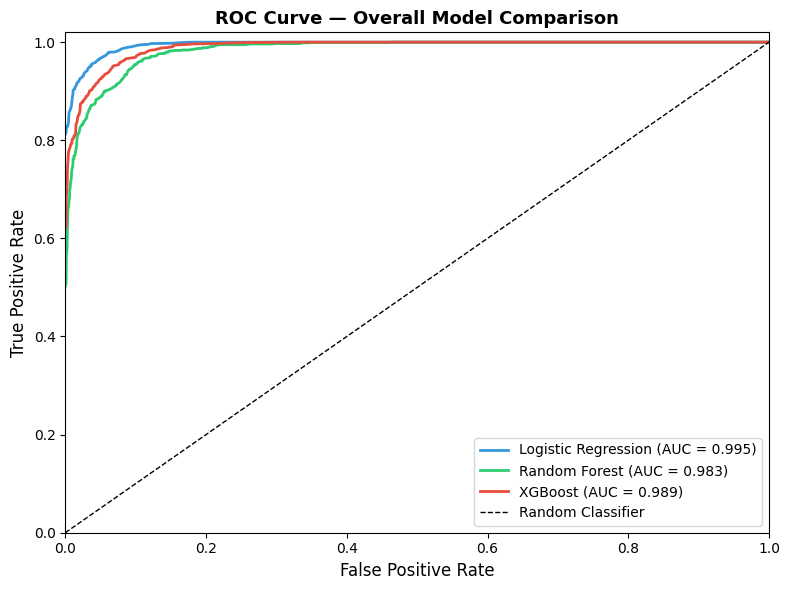

In [20]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Binarize y_test for multiclass ROC (one-vs-rest)
y_test_binarized = label_binarize(y_test_encoded, classes=[0, 1, 2])

models = {
    'Logistic Regression': grid_search_lr.best_estimator_,
    'Random Forest': grid_search_rf.best_estimator_,
    'XGBoost': random_search_xgb.best_estimator_
}

colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 6))

for (model_name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_selected)
    
    # Compute macro-averaged ROC curve across all three classes
    all_fpr = np.unique(np.concatenate([
        roc_curve(y_test_binarized[:, i], y_prob[:, i])[0]
        for i in range(3)
    ]))
    
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= 3
    
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=color, lw=2,
            label=f'{model_name} (AUC = {macro_auc:.3f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Overall Model Comparison',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

**ROC-AUC Curve:** All three models demonstrate strong discriminative ability, with Logistic Regression achieving the highest AUC of 0.995. This confirms that it not only classifies most accurately but also separates risk categories most confidently across all decision thresholds.

### 4.2 Best Model Evaluation - Logistic Regression

### 4.2.1 Confusion Matrix 

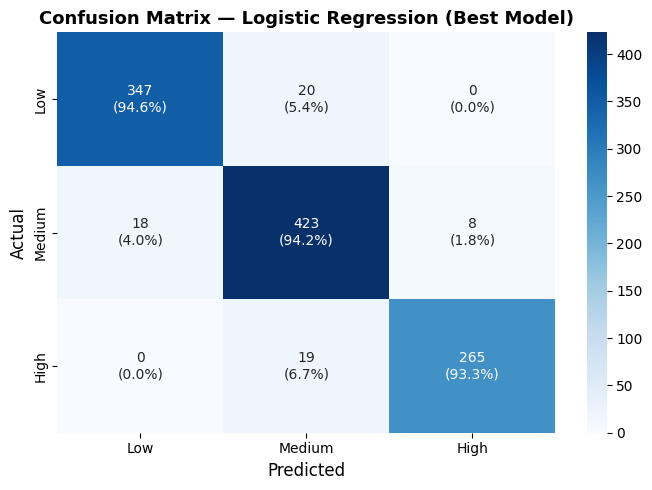

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions from best model (Logistic Regression)
y_pred_best = grid_search_lr.best_estimator_.predict(X_test_selected)

cm = confusion_matrix(y_test_encoded, y_pred_best)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = [[f"{count}\n({pct:.1f}%)" for count, pct in zip(row_counts, row_pcts)]
          for row_counts, row_pcts in zip(cm, cm_percent)]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High'],
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression (Best Model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- **High overall accuracy across all classes**: The model correctly classifies about 93–95% of patients in each category (Low, Medium, High), showing balanced performance across risk levels.

- **No critical Low–High misclassifications**: The model never confused Low risk with High risk. This is the most important result because these would be the most serious mistakes in a medical context.

- **Errors occur only between neighboring categories**: When mistakes happen, they are mainly between Low ↔ Medium or Medium ↔ High, which is expected since these categories are closest in risk.

- **Medium risk is the hardest class to predict**: Most misclassifications involve the Medium category, which sits between Low and High and naturally overlaps with both.

### 4.2.2 SHAP

In [23]:
import shap

# Initialize the explainer for logistic regression
explainer = shap.LinearExplainer(
    grid_search_lr.best_estimator_,
    X_train_selected
)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test_selected)

print("SHAP values shape:", np.array(shap_values).shape)

C:\Users\lilik\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (1100, 14, 3)


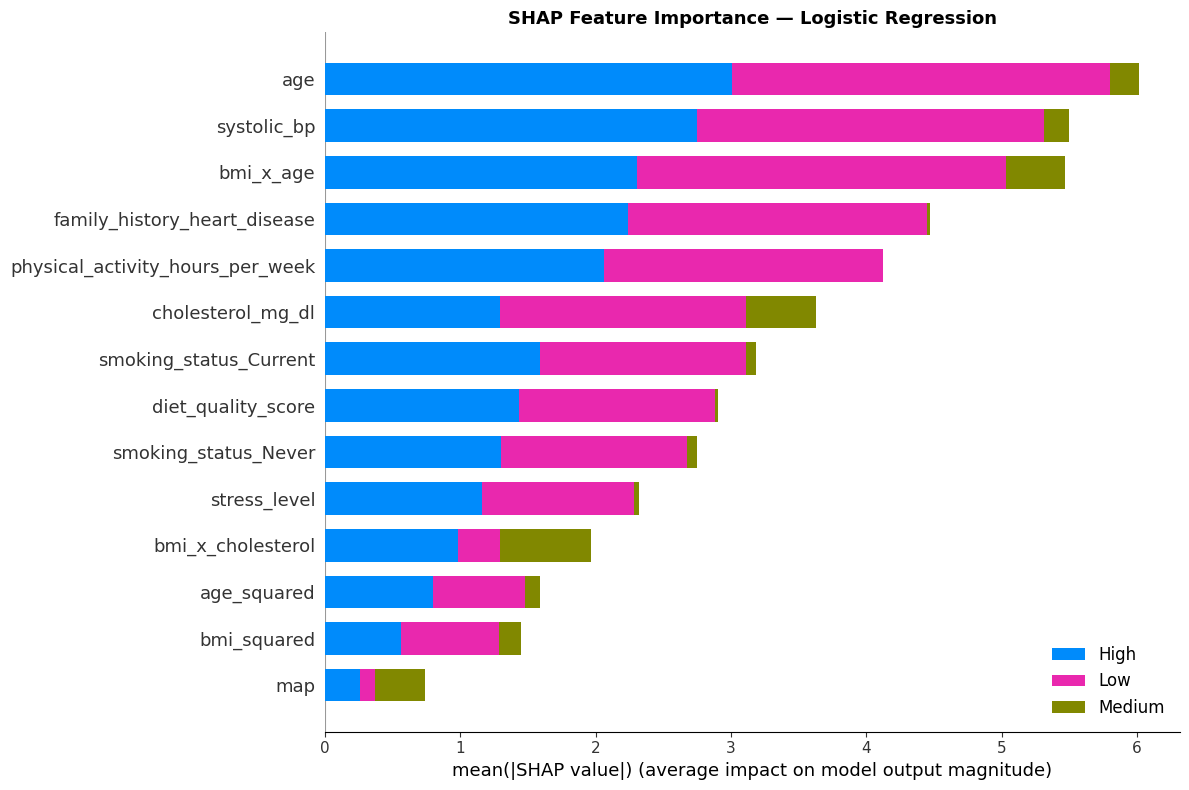

In [25]:
# Summary plot — global feature importance across all classes
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test_selected,
    class_names=['Low', 'Medium', 'High'],
    plot_type='bar',
    show=False
)

plt.title('SHAP Feature Importance — Logistic Regression', 
          fontsize=13, fontweight='bold')
plt.gcf().set_size_inches(12, 8) 
plt.tight_layout()
plt.show()

SHAP analysis shows which features influence the model’s predictions the most. The results indicate that **age and systolic blood pressure are the strongest predictors**, followed by the **BMI–age interaction and family history of heart disease**. Lifestyle factors such as **physical activity, cholesterol, smoking, and diet quality** also contribute, but to a smaller extent. Overall, the findings align well with medical knowledge that age, blood pressure, and metabolic factors are key drivers of cardiovascular risk.

# 5 Conclusion 

In [26]:
# Performance metrics table
performance = pd.DataFrame({
    'Model': [
        'Logistic Regression (Tuned)',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)'
    ],
    'F1 Macro':  [0.9428, 0.9060, 0.9119],
    'F2 Score':  [0.9412, 0.9031, 0.9083],
    'Recall':    [0.94, 0.90, 0.91],
    'ROC-AUC':   [0.9948, 0.9831, 0.9888],
    'Accuracy':  [0.94, 0.90, 0.91],
}).sort_values('F1 Macro', ascending=False)

# Overfitting table
overfitting = pd.DataFrame({
    'Model': [
        'Logistic Regression (Tuned)',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)'
    ],
    'Train F1':  [0.9432, 1.0000, 0.9479],
    'Test F1':   [0.9428, 0.9060, 0.9119],
    'Gap':       [0.0005, 0.0940, 0.0360]
}).sort_values('Test F1', ascending=False)

print("Performance Metrics")
print("-" * 75)
print(performance.to_string(index=False))
print("\nOverfitting Check")
print("-" * 55)
print(overfitting.to_string(index=False))

Performance Metrics
---------------------------------------------------------------------------
                      Model  F1 Macro  F2 Score  Recall  ROC-AUC  Accuracy
Logistic Regression (Tuned)    0.9428    0.9412    0.94   0.9948      0.94
            XGBoost (Tuned)    0.9119    0.9083    0.91   0.9888      0.91
      Random Forest (Tuned)    0.9060    0.9031    0.90   0.9831      0.90

Overfitting Check
-------------------------------------------------------
                      Model  Train F1  Test F1    Gap
Logistic Regression (Tuned)    0.9432   0.9428 0.0005
            XGBoost (Tuned)    0.9479   0.9119 0.0360
      Random Forest (Tuned)    1.0000   0.9060 0.0940


Three classification models were trained, tuned and evaluated on a held-out test set to predict heart disease risk category (Low, Medium, High). 
Our primary metric throughout was **F1 Macro**, chosen to ensure equal importance across all three risk categories.

**Key Findings:**

- **Logistic Regression** is the best performing model with an F1 Macro of **0.9428** and a near-zero train/test gap of 0.0005, indicating near-perfect 
  generalization with no overfitting.

- **XGBoost** achieved an F1 Macro of **0.9119**, ranking second. Despite being a more complex model, it shows a moderate train/test gap of 0.0360, suggesting mild overfitting even after tuning.

- **Random Forest** performed the weakest with an F1 Macro of **0.9060** and a concerning train/test gap of 0.0940. The perfect training score of 1.0000 indicates clear overfitting that tuning did not fully resolve.

**Conclusion:**

Logistic Regression is the superior model for this dataset. The strong linear relationships between heart disease risk factors such as BMI, cholesterol, blood pressure, and smoking status and the target variable mean that added complexity from ensemble methods does not improve generalization and instead introduces overfitting. SHAP analysis confirms that age, systolic blood pressure, and the BMI–age interaction are the most influential predictors, aligning closely with established clinical knowledge about cardiovascular risk.

The model's strong performance combined with its interpretability and perfect generalization makes it well suited for deployment in a clinical setting where medical personnel require transparent and explainable risk predictions.